<a href="https://colab.research.google.com/github/rhmau1/PCVK_26/blob/main/Modul5/MODUL5_E1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : FIJRIATI RAHMATUR RIZQI
NIM  : 244107020069 | N = 69
bins   : 16
clip   : 3.0
tile   : 3
L      : 2
WAKTU  : 2026-09-25 09:13:29 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 5f7566785e6609b7


Text(0.5, 1.0, '244107020069- CLAHE clip3.0')

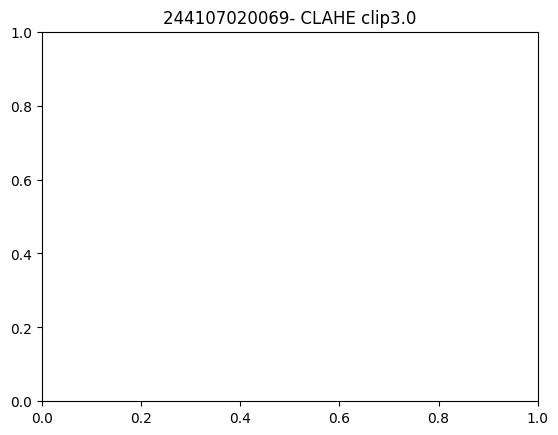

In [4]:
# sel identitas jangan dihapus harus sel pertama
import sys, platform, hashlib, datetime, zoneinfo
import matplotlib.pyplot as plt
NAMA = 'FIJRIATI RAHMATUR RIZQI'
NIM = '244107020069'

N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N%4) + 3),
    'clip': round(1.0 + (N%5) * 0.5, 1),
    'tile': (N % 4) +2,
    'L': 2**((N%3)+1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + '- CLAHE clip' + str(PARAM['clip']))

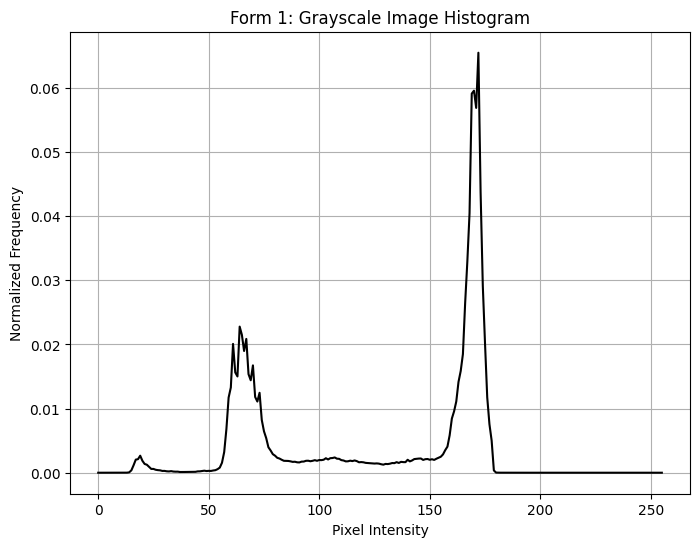

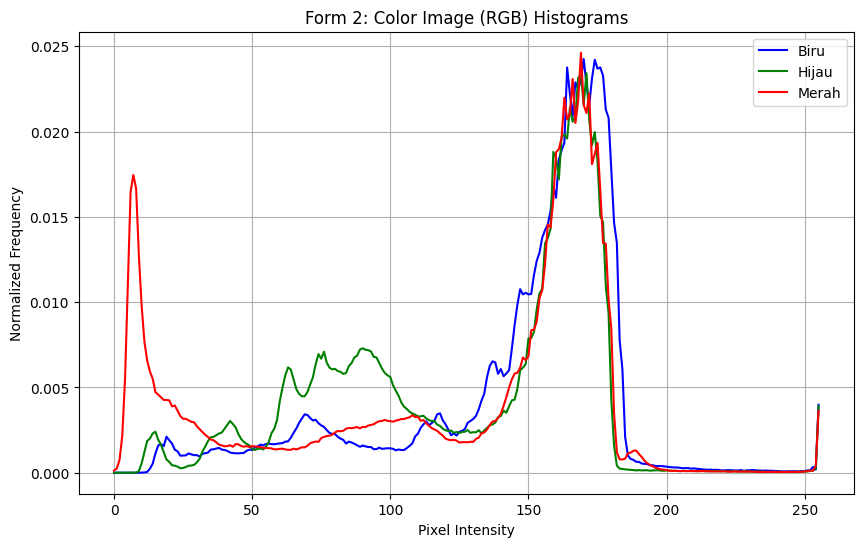

In [7]:
import numpy as np, cv2 as cv, matplotlib.pyplot as plt

def histogram_manual(img, L = 256):
  h = np.zeros(L, dtype=np.int64) # siapkan penghitung, isi 0
  for y in range(img.shape[0]): # telusuri tiap baris
    for x in range(img.shape[1]): # dan kolom
      h[img[y,x]] += 1  # tambah 1 sesuai nilai piksel
  return h

# --- Form 1: Grayscale Histogram ---
gray_image_path = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1B.jpeg'
gray = cv.imread(gray_image_path, cv.IMREAD_GRAYSCALE)

if gray is None:
    print(f"Error: Could not load grayscale image from {gray_image_path}")
else:
    h_gray = histogram_manual(gray)
    p_gray = h_gray / gray.size # normalisasi, jumlahnya = 1
    cdf_gray = np.cumsum(p_gray) # distribusi kumulatif, as per original code
    assert h_gray.sum() == gray.size # pemeriksaan wajib

    plt.figure(figsize=(8, 6))
    plt.title('Form 1: Grayscale Image Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Normalized Frequency')
    plt.plot(p_gray, color='black')
    plt.grid(True)
    plt.show()

# --- Form 2: Color (RGB) Histograms ---
color_image_path = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1C.jpeg'
bgr = cv.imread(color_image_path)

if bgr is None:
    print(f"Error: Could not load color image from {color_image_path}")
else:
    # Extract channels (OpenCV reads as BGR)
    blue_channel = bgr[:,:,0]
    green_channel = bgr[:,:,1]
    red_channel = bgr[:,:,2]

    # Calculate histograms for B, G, R
    h_blue = histogram_manual(blue_channel)
    h_green = histogram_manual(green_channel)
    h_red = histogram_manual(red_channel)

    # Assert sums for each channel
    assert h_blue.sum() == blue_channel.size
    assert h_green.sum() == green_channel.size
    assert h_red.sum() == red_channel.size

    # Normalize histograms
    p_blue = h_blue / blue_channel.size
    p_green = h_green / green_channel.size
    p_red = h_red / red_channel.size

    # A dictionary to store the normalized histograms as requested
    normalized_histograms = {
        'Biru': p_blue,
        'Hijau': p_green,
        'Merah': p_red
    }

    plt.figure(figsize=(10, 6))
    plt.title('Form 2: Color Image (RGB) Histograms')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Normalized Frequency')

    # Plotting B, G, R histograms using labels 'Biru', 'Hijau', 'Merah' as specified in the user's algorithm
    plt.plot(normalized_histograms['Biru'], color='blue', label='Biru')
    plt.plot(normalized_histograms['Hijau'], color='green', label='Hijau')
    plt.plot(normalized_histograms['Merah'], color='red', label='Merah')

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math, os, glob

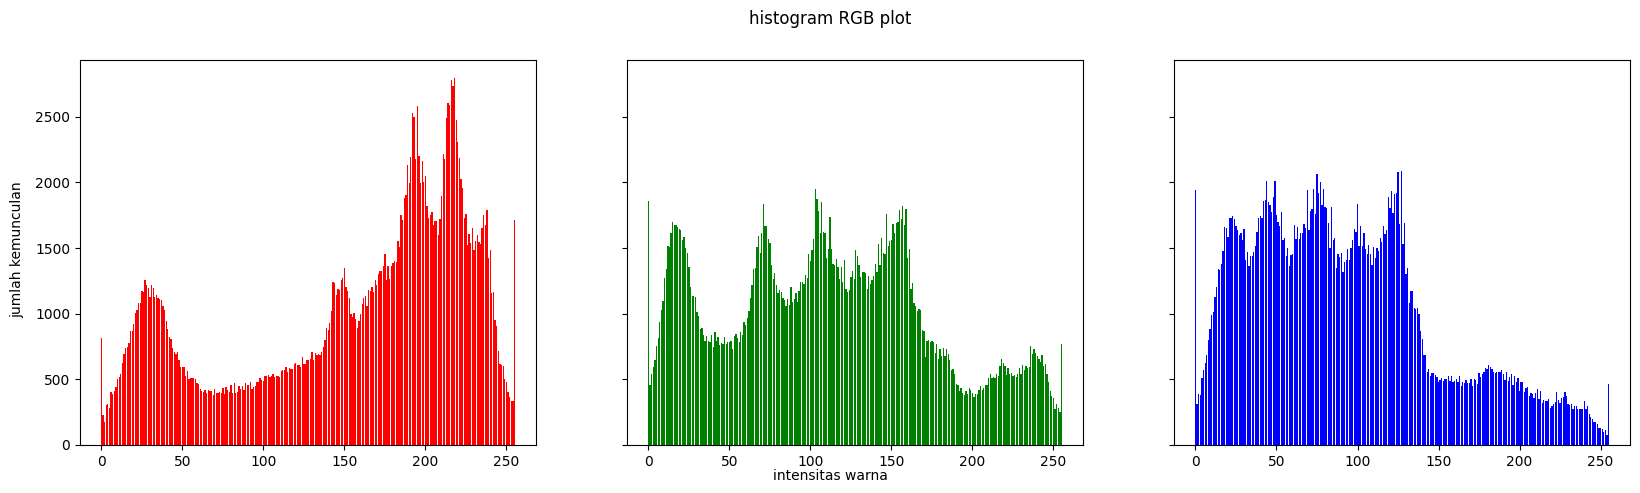

In [11]:
img = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y,x,0]] += 1
    green[img[y,x,1]] += 1
    blue[img[y,x,2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1,3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('histogram RGB plot')
fig.text(0.09, 0.5, 'jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'intensitas warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()
